# Introducción al análisis de datos censales con Python

## ¿De qué se trata esta notebook?

Esta guía es una introducción práctica al análisis de datos usando el **Censo Nacional de Población, Hogares y Viviendas 2022** de Argentina (INDEC).

No se necesita saber estadística avanzada ni tener experiencia previa con datos censales. Alcanza con conocer Python básico.

Al final de esta guía vas a poder:
- Consultar variables del censo directamente desde Python
- Obtener tablas con N y porcentajes
- Comparar indicadores entre provincias y departamentos
- Generar visualizaciones básicas

---

## ¿Qué es `censoargentino`?

Es un paquete Python que conecta directamente con los datos del censo procesados en formato Parquet y almacenados en [Hugging Face](https://huggingface.co/datasets/pedroorden/censoargentino). Usa DuckDB internamente para hacer consultas eficientes: **no descarga el dataset completo** (137 MB), solo los bloques que corresponden a tu consulta.

```
INDEC (base REDATAM)  →  procesamiento  →  Hugging Face  →  censoargentino  →  tu análisis
```

---
## 0. Instalación

Si todavía no tenés el paquete instalado:

In [2]:
# Descomenta si necesitás instalar
# !pip install censoargentino

In [3]:
import censoargentino as censo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Estilo general de los gráficos
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

print("Todo listo.")

Todo listo.


---
## 1. ¿Qué datos tenemos?

Antes de analizar, conviene entender qué variables están disponibles. El censo 2022 tiene tres **entidades** principales:

| Entidad | Qué mide |
|---|---|
| `PERSONA` | Características de cada persona: sexo, edad, educación, actividad económica |
| `HOGAR` | Características del hogar: NBI, hacinamiento, acceso a servicios |
| `VIVIENDA` | Tipo y calidad de la vivienda, acceso a agua y saneamiento |

Usamos `censo.variables()` para ver el catálogo completo.

In [4]:
# Ver todas las variables disponibles
vars_df = censo.variables()
print(f"Total de variables: {len(vars_df)}")
vars_df

[censo] Descargando catalogo de variables (archivo de metadatos, ~1 MB)...
[censo] Iniciando DuckDB e instalando extension HTTP...
[censo] Listo. Las consultas van directo a Hugging Face (pedroorden/censoargentino).
[censo] Catalogo cargado en 0.7s -> 86 variables disponibles
[censo]   Entidades: PERSONA (personas), HOGAR (hogares), VIVIENDA (viviendas)
Total de variables: 86


,codigo_variable,etiqueta_variable,entidad
0,DPTO_IDPTO,Departamento,DPTO
1,DPTO_NDPTO,Departamento,DPTO
2,DPTO_REDCODEN,Departamento,DPTO
3,FRAC_IDFRAC,Fraccion,FRAC
4,FRAC_REDCODEN,Fracción,FRAC
...,...,...,...
81,VIVIENDA_V01,Tipo de vivienda,VIVIENDA
82,VIVIENDA_V01_1,Tipo de vivienda particular ocupada,VIVIENDA
83,VIVIENDA_V02,Condición de ocupación,VIVIENDA
84,VIVIENDA_V04,Motivo por el que no realizó la entrevista,VIVIENDA


In [5]:
# Cuántas variables hay por entidad
vars_df.groupby("entidad").size().rename("variables").reset_index()

,entidad,variables
0,DPTO,3
1,FRAC,2
2,HOGAR,30
3,PERSONA,33
4,PROV,3
5,RADIO,2
6,VIVIENDA,13


In [6]:
# Buscar variables sobre educación
censo.variables(buscar="instruccion")

,codigo_variable,etiqueta_variable,entidad


Cuando encontramos una variable que nos interesa, usamos `describe()` para entender exactamente qué mide y cuáles son sus categorías posibles.

In [7]:
# ¿Qué mide exactamente PERSONA_MNI?
censo.describe("PERSONA_MNI")

[censo] Consultando metadatos de 'PERSONA_MNI'...

  Variable    : PERSONA_MNI
  Nombre INDEC: MNI
  Descripcion : Máximo nivel de instrucción alcanzado
  Entidad     : PERSONA  (aplica a personas)
  Referencia  : https://redatam.indec.gob.ar/redarg/CENSOS/CPV2022/Docs/Redatam_Definiciones_de_la_base_de_datos.pdf

  Categorias (12 valores):
  Codigo      Etiqueta
  --------  ----------------------------------------
  1           Sin instrucción
  2           Primario incompleto
  3           Primario completo
  4           Secundario incompleto
  5           Secundario completo
  6           Terciario incompleto
  7           Terciario completo
  8           Universitario incompleto
  9           Universitario completo
  10          Posgrado incompleto
  11          Posgrado completo
  99          Ignorado



---
## 2. Primera consulta: distribución de sexo

Empezamos con algo simple. La variable `PERSONA_P02` registra el sexo al nacer.

Usamos `censo.tabla()` que en un solo paso descarga los datos y calcula N y porcentaje.

In [8]:
# Distribución de sexo a nivel nacional
sexo = censo.tabla("PERSONA_P02")
sexo

[censo] =======================================================
[censo] Consulta al Censo Nacional 2022 (INDEC)
[censo] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[censo]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[censo] -------------------------------------------------------
[censo]   Variable : PERSONA_P02  ("Sexo registrado al nacer")
[censo] -------------------------------------------------------
[censo] Estructura del resultado:
[censo]   Cada fila = una (radio censal x categoria de variable x conteo)
[censo]   Columnas clave: id_geo | codigo_variable | valor_categoria
[censo]                   etiqueta_categoria | conteo
[censo] =======================================================
[censo] Descargando datos desde Hugging Face...
[censo] Descarga completa en 4.0s -> 132,571 filas | 13 columnas | 84.2 MB en memoria


,categoria,N,%
0,Mujer / Femenino,23607906,51.8
1,Varón / Masculino,22010881,48.2


El resultado tiene tres columnas:
- **`categoria`**: el valor de la variable (en este caso, Mujer o Varón)
- **`N`**: cantidad de personas en esa categoría
- **`%`**: porcentaje sobre el total

Podemos visualizarlo en un gráfico de barras:

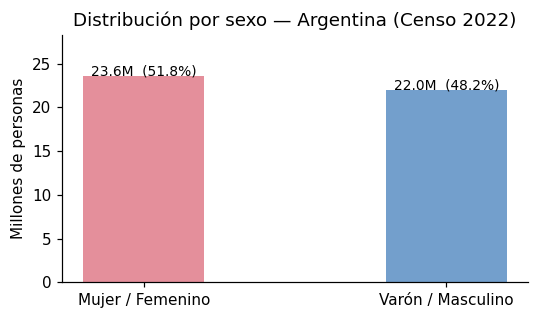

In [9]:
fig, ax = plt.subplots(figsize=(5, 3))
colores = ["#e07b8a", "#5b8ec4"]
ax.bar(sexo["categoria"], sexo["N"] / 1e6, color=colores, alpha=0.85, width=0.4)

for i, (n, pct) in enumerate(zip(sexo["N"], sexo["%"])):
    ax.text(i, n / 1e6 + 0.1, f"{n/1e6:.1f}M  ({pct}%)", ha="center", fontsize=9)

ax.set_ylabel("Millones de personas")
ax.set_title("Distribución por sexo — Argentina (Censo 2022)")
ax.set_ylim(0, sexo["N"].max() / 1e6 * 1.2)
plt.tight_layout()
plt.show()

---
## 3. Filtrar por provincia

Todas las funciones aceptan un parámetro `provincia`. Podés pasar el nombre o el código INDEC de 2 dígitos.

In [10]:
# Ver los códigos disponibles
censo.provincias()

,codigo,provincia
0,02,Ciudad Autónoma De Buenos Aires
1,06,Buenos Aires
2,10,Catamarca
3,14,Córdoba
4,18,Corrientes
5,22,Chaco
6,26,Chubut
7,30,Entre Ríos
8,34,Formosa
9,38,Jujuy


In [11]:
# Sexo en CABA (código "02") y en Tucumán (por nombre)
sexo_caba   = censo.tabla("PERSONA_P02", provincia="02")
sexo_tucuman = censo.tabla("PERSONA_P02", provincia="Tucumán")

print("=== CABA ===")
print(sexo_caba.to_string(index=False))
print("\n=== Tucumán ===")
print(sexo_tucuman.to_string(index=False))

[censo] =======================================================
[censo] Consulta al Censo Nacional 2022 (INDEC)
[censo] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[censo]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[censo] -------------------------------------------------------
[censo]   Variable : PERSONA_P02  ("Sexo registrado al nacer")
[censo]   Provincia: Ciudad Autónoma De Buenos Aires  (codigo INDEC: 02)
[censo] -------------------------------------------------------
[censo] Estructura del resultado:
[censo]   Cada fila = una (radio censal x categoria de variable x conteo)
[censo]   Columnas clave: id_geo | codigo_variable | valor_categoria
[censo]                   etiqueta_categoria | conteo
[censo] =======================================================
[censo] Descargando datos desde Hugging Face...
[censo] Descarga completa en 0.3s -> 7,640 filas | 13 columnas | 4.8 MB en memoria
[censo] ================================================

---
## 4. Comparar provincias con `comparar()`

`comparar()` devuelve una tabla pivot donde cada fila es una provincia y cada columna es una categoría de la variable. Los valores son porcentajes.

Es ideal para ver patrones geográficos de un vistazo.

In [12]:
# Porcentaje de hogares con NBI por provincia
# NBI = Necesidades Básicas Insatisfechas
nbi_prov = censo.comparar("HOGAR_NBI_TOT")
nbi_prov

[censo] =======================================================
[censo] Consulta al Censo Nacional 2022 (INDEC)
[censo] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[censo]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[censo] -------------------------------------------------------
[censo]   Variable : HOGAR_NBI_TOT  ("Necesidades básicas insatisfechas")
[censo] -------------------------------------------------------
[censo] Estructura del resultado:
[censo]   Cada fila = una (radio censal x categoria de variable x conteo)
[censo]   Columnas clave: id_geo | codigo_variable | valor_categoria
[censo]                   etiqueta_categoria | conteo
[censo] =======================================================
[censo] Descargando datos desde Hugging Face...
[censo] Descarga completa en 3.9s -> 127,347 filas | 13 columnas | 79.3 MB en memoria


,No,Sí,Total
Buenos Aires,93.7,6.3,6051550
Caba,95.2,4.8,1406735
Córdoba,95.7,4.3,1394400
Santa Fe,95.1,4.9,1289967
Mendoza,93.6,6.4,652184
Tucumán,90.5,9.5,505542
Entre Ríos,94.0,6.0,500660
Misiones,91.3,8.7,425667
Salta,85.8,14.2,418430
Corrientes,88.2,11.8,379129


La columna **`Total`** es la cantidad de hogares de esa provincia. Las demás columnas son el % en cada categoría.

Podemos graficar solo la columna que nos interesa:

Columna NBI: 'No'


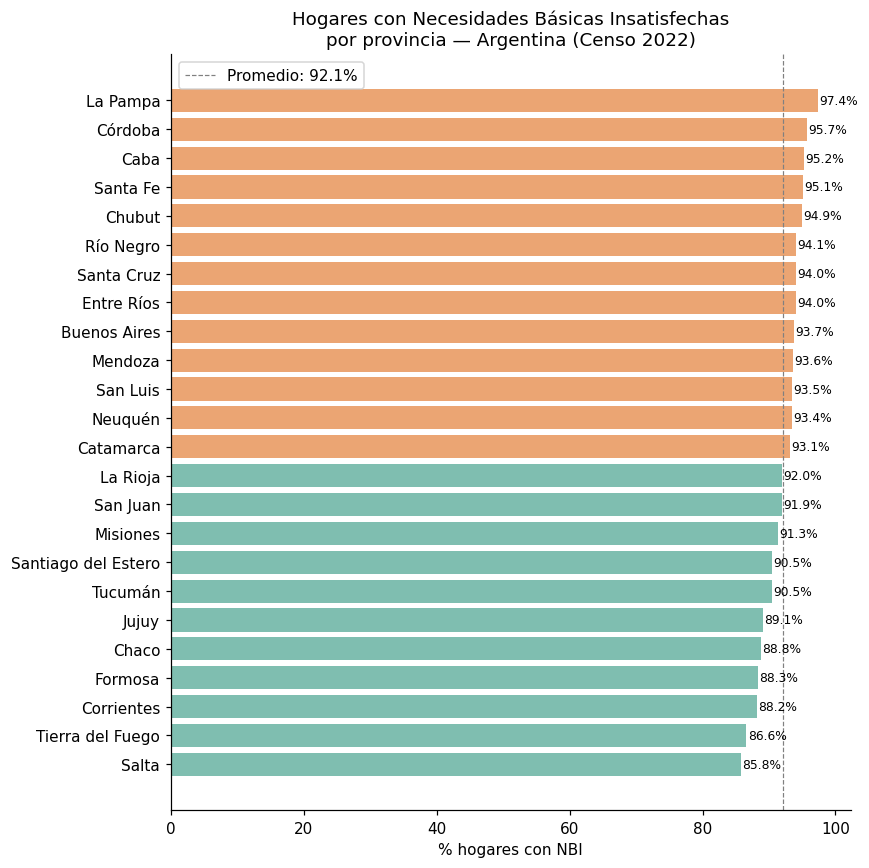

In [13]:
# Identificar la columna con NBI positivo (la que no dice "Sin")
col_nbi = [c for c in nbi_prov.columns if "Sin" not in c and c != "Total"][0]
print(f"Columna NBI: '{col_nbi}'")

plot_df = nbi_prov[[col_nbi]].sort_values(col_nbi)
media = plot_df[col_nbi].mean()

fig, ax = plt.subplots(figsize=(8, 8))
colores = ["#e8965a" if v > media else "#69b3a2" for v in plot_df[col_nbi]]
ax.barh(plot_df.index, plot_df[col_nbi], color=colores, alpha=0.85)
ax.axvline(media, color="grey", linestyle="--", linewidth=0.8,
           label=f"Promedio: {media:.1f}%")

for prov, val in plot_df[col_nbi].items():
    ax.text(val + 0.2, list(plot_df.index).index(prov), f"{val}%",
            va="center", fontsize=8)

ax.set_xlabel("% hogares con NBI")
ax.set_title("Hogares con Necesidades Básicas Insatisfechas\npor provincia — Argentina (Censo 2022)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Bajar al nivel de departamento

Cuando queremos más granularidad dentro de una provincia, usamos `nivel="departamento"`.

In [23]:
# NBI por departamento dentro de Salta
# Salta tiene alta heterogeneidad interna
nbi_salta = censo.comparar("HOGAR_NBI_TOT", nivel="departamento", provincia="Salta")
nbi_salta

[censo] =======================================================
[censo] Consulta al Censo Nacional 2022 (INDEC)
[censo] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[censo]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[censo] -------------------------------------------------------
[censo]   Variable : HOGAR_NBI_TOT  ("Necesidades básicas insatisfechas")
[censo]   Provincia: Salta  (codigo INDEC: 66)
[censo] -------------------------------------------------------
[censo] Estructura del resultado:
[censo]   Cada fila = una (radio censal x categoria de variable x conteo)
[censo]   Columnas clave: id_geo | codigo_variable | valor_categoria
[censo]                   etiqueta_categoria | conteo
[censo] =======================================================
[censo] Descargando datos desde Hugging Face...
[censo] Descarga completa en 0.3s -> 3,607 filas | 13 columnas | 2.2 MB en memoria


,No,Sí,Total
028,90.9,9.1,188314
056,78.4,21.6,50449
126,80.1,19.9,44245
007,80.2,19.8,19357
049,87.8,12.2,15595
035,84.5,15.5,15211
147,87.3,12.7,14173
112,85.6,14.4,13857
133,60.1,39.9,11075
140,89.5,10.5,10384


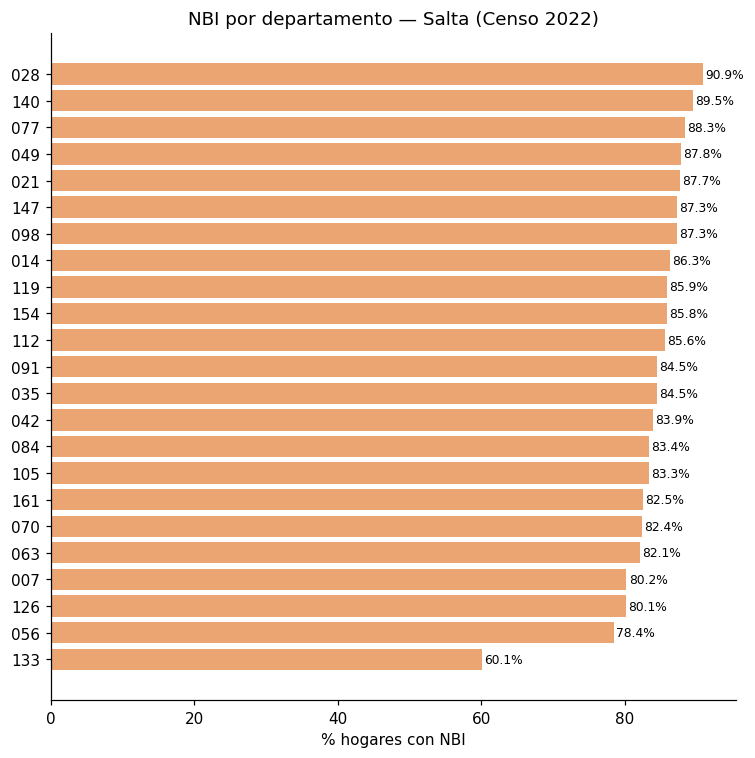

In [15]:
# Graficamos los departamentos de Salta
col_nbi = [c for c in nbi_salta.columns if "Sin" not in c and c != "Total"][0]
plot_dpto = nbi_salta[[col_nbi]].sort_values(col_nbi)

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(plot_dpto.index, plot_dpto[col_nbi], color="#e8965a", alpha=0.85)
for dpto, val in plot_dpto[col_nbi].items():
    ax.text(val + 0.3, list(plot_dpto.index).index(dpto), f"{val}%",
            va="center", fontsize=8)
ax.set_xlabel("% hogares con NBI")
ax.set_title("NBI por departamento — Salta (Censo 2022)")
plt.tight_layout()
plt.show()

---
## 5b. Ejercicio: los 5 departamentos con más y menos NBI

Un análisis común es identificar los extremos: ¿qué departamentos concentran más carencias? ¿y cuáles están mejor? Esto ayuda a priorizar políticas públicas o a enfocar investigaciones.

Usamos `comparar()` con `nivel="departamento"` y luego ordenamos por la columna de interés.

> Podés cambiar la variable `PROVINCIA` para explorar cualquier provincia.

In [ ]:
# Cambiá esta variable para explorar otra provincia
PROVINCIA = "Salta"

nbi_dpto = censo.comparar("HOGAR_NBI_TOT", nivel="departamento", provincia=PROVINCIA)

# Identificamos la columna de NBI positivo
col_nbi = [c for c in nbi_dpto.columns if c not in ("Total", "No", "Sin NBI") and "Sin" not in c][0]
print(f"Variable analizada: NBI — columna '{col_nbi}'\n")

top5    = nbi_dpto[[col_nbi, "Total"]].sort_values(col_nbi, ascending=False).head(5)
bottom5 = nbi_dpto[[col_nbi, "Total"]].sort_values(col_nbi, ascending=True).head(5)

print(f"=== 5 departamentos con MÁS NBI — {PROVINCIA} ===")
print(top5.to_string())
print(f"\n=== 5 departamentos con MENOS NBI — {PROVINCIA} ===")
print(bottom5.to_string())

In [ ]:
# Visualización: top 5 y bottom 5 lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Top 5 — más NBI
top5_plot = top5.sort_values(col_nbi)
axes[0].barh(top5_plot.index, top5_plot[col_nbi], color="#c0392b", alpha=0.85)
for dpto, val in top5_plot[col_nbi].items():
    axes[0].text(val + 0.3, list(top5_plot.index).index(dpto),
                 f"{val}%", va="center", fontsize=9)
axes[0].set_xlabel("% hogares con NBI")
axes[0].set_title(f"Con más NBI — {PROVINCIA}")
axes[0].set_xlim(0, top5_plot[col_nbi].max() * 1.3)

# Bottom 5 — menos NBI
bottom5_plot = bottom5.sort_values(col_nbi, ascending=False)
axes[1].barh(bottom5_plot.index, bottom5_plot[col_nbi], color="#69b3a2", alpha=0.85)
for dpto, val in bottom5_plot[col_nbi].items():
    axes[1].text(val + 0.1, list(bottom5_plot.index).index(dpto),
                 f"{val}%", va="center", fontsize=9)
axes[1].set_xlabel("% hogares con NBI")
axes[1].set_title(f"Con menos NBI — {PROVINCIA}")
axes[1].set_xlim(0, top5_plot[col_nbi].max() * 1.3)  # misma escala para comparar

fig.suptitle(f"Departamentos con mayor y menor NBI — {PROVINCIA} (Censo 2022)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 6. Datos crudos y agregación manual

Para análisis más avanzados, `query()` devuelve el dataset en **formato largo por radio censal**: la unidad mínima geográfica del censo (~52.000 radios en todo el país).

Cada radio es un área pequeña de entre 200 y 300 viviendas.

`agregar()` permite resumir ese dataset sin tener que volver a descargarlo.

In [16]:
# Descargamos datos de educación para Misiones
df_educ = censo.query(variables="PERSONA_MNI", provincia="Misiones")

print(f"Filas (radios × categorías): {len(df_educ):,}")
print(f"Columnas: {list(df_educ.columns)}")
df_educ.head(4)

[censo] =======================================================
[censo] Consulta al Censo Nacional 2022 (INDEC)
[censo] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[censo]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[censo] -------------------------------------------------------
[censo]   Variable : PERSONA_MNI  ("Máximo nivel de instrucción alcanzado")
[censo]   Provincia: Misiones  (codigo INDEC: 54)
[censo] -------------------------------------------------------
[censo] Estructura del resultado:
[censo]   Cada fila = una (radio censal x categoria de variable x conteo)
[censo]   Columnas clave: id_geo | codigo_variable | valor_categoria
[censo]                   etiqueta_categoria | conteo
[censo] =======================================================
[censo] Descargando datos desde Hugging Face...
[censo] Descarga completa en 3.9s -> 21,554 filas | 13 columnas | 13.5 MB en memoria
Filas (radios × categorías): 21,554
Columnas: ['id_geo', 'valor_

,id_geo,valor_provincia,etiqueta_provincia,valor_departamento,etiqueta_departamento,valor_fraccion,etiqueta_fraccion,valor_radio,etiqueta_radio,codigo_variable,valor_categoria,etiqueta_categoria,conteo
0,540070101,54,Misiones,007,007,01,01,01,01,PERSONA_MNI,1,Sin instrucción,14
1,540070102,54,Misiones,007,007,01,01,02,02,PERSONA_MNI,1,Sin instrucción,56
2,540070103,54,Misiones,007,007,01,01,03,03,PERSONA_MNI,1,Sin instrucción,86
3,540070104,54,Misiones,007,007,01,01,04,04,PERSONA_MNI,1,Sin instrucción,36


In [17]:
# Totales provinciales — mismos datos, pero resumidos
educ_total = censo.agregar(df_educ)
# Excluimos la categoría "ignorado" (código 99)
educ_total = educ_total[~educ_total["categoria"].str.contains("gnor", case=False)]
educ_total

,categoria,N,%
0,Sin instrucción,162715,12.8
1,Primario incompleto,316469,24.9
2,Primario completo,163772,12.9
3,Secundario incompleto,244206,19.2
4,Secundario completo,156198,12.3
5,Terciario incompleto,54166,4.3
6,Terciario completo,61031,4.8
7,Universitario incompleto,57436,4.5
8,Universitario completo,35898,2.8
9,Posgrado incompleto,7052,0.6


In [18]:
# El mismo df, ahora abierto por departamento — sin nueva descarga
educ_dpto = censo.agregar(df_educ, por="departamento")
educ_dpto[~educ_dpto["categoria"].str.contains("gnor", case=False)].head(20)

,etiqueta_departamento,categoria,N,%
0,007,Sin instrucción,6296,12.5
1,007,Primario incompleto,12129,24.0
2,007,Primario completo,7303,14.5
3,007,Secundario incompleto,10062,19.9
4,007,Secundario completo,6514,12.9
5,007,Terciario incompleto,2126,4.2
6,007,Terciario completo,2915,5.8
7,007,Universitario incompleto,1535,3.0
8,007,Universitario completo,976,1.9
9,007,Posgrado incompleto,224,0.4


---
## 7. Mini análisis: ¿Cuáles son las provincias con más privación material?

El IPMH (Índice de Privación Material de los Hogares) combina dos dimensiones:
- **Privación patrimonial**: vivienda inadecuada
- **Privación de recursos corrientes**: ingresos insuficientes

Tiene cuatro categorías: sin privación, solo patrimonial, solo recursos corrientes, y convergente (ambas).

In [19]:
# Ver qué mide exactamente
censo.describe("HOGAR_IPMH")

[censo] Consultando metadatos de 'HOGAR_IPMH'...

  Variable    : HOGAR_IPMH
  Nombre INDEC: IPMH
  Descripcion : Indice de privación material de los hogares
  Entidad     : HOGAR  (aplica a hogares)
  Referencia  : https://redatam.indec.gob.ar/redarg/CENSOS/CPV2022/Docs/Redatam_Definiciones_de_la_base_de_datos.pdf

  Categorias (4 valores):
  Codigo      Etiqueta
  --------  ----------------------------------------
  1           Sin privación
  2           Privación solo de recursos corrientes
  3           Privación solo recursos patrimoniales
  4           Privación Convergente



In [20]:
# Distribución nacional
ipmh_nac = censo.tabla("HOGAR_IPMH")
ipmh_nac

[censo] =======================================================
[censo] Consulta al Censo Nacional 2022 (INDEC)
[censo] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[censo]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[censo] -------------------------------------------------------
[censo]   Variable : HOGAR_IPMH  ("Indice de privación material de los hogares")
[censo] -------------------------------------------------------
[censo] Estructura del resultado:
[censo]   Cada fila = una (radio censal x categoria de variable x conteo)
[censo]   Columnas clave: id_geo | codigo_variable | valor_categoria
[censo]                   etiqueta_categoria | conteo
[censo] =======================================================
[censo] Descargando datos desde Hugging Face...
[censo] Descarga completa en 0.5s -> 251,527 filas | 13 columnas | 164.0 MB en memoria


,categoria,N,%
0,Sin privación,10438909,65.5
1,Privación solo de recursos corrientes,2541233,16.0
2,Privación solo recursos patrimoniales,1629074,10.2
3,Privación Convergente,1323086,8.3


In [21]:
# Comparación por provincia
ipmh_prov = censo.comparar("HOGAR_IPMH")

# Columna de privación convergente (la más grave: ambas privaciones)
col_conv = [c for c in ipmh_prov.columns if "Convergente" in c or "convergente" in c]
if not col_conv:
    col_conv = [c for c in ipmh_prov.columns if c != "Total"]
    print("Categorías disponibles:", list(ipmh_prov.columns))
else:
    col_conv = col_conv[0]
    print(f"Columna privación convergente: '{col_conv}'")
    ipmh_prov[[col_conv, "Total"]].sort_values(col_conv, ascending=False).head(10)

[censo] =======================================================
[censo] Consulta al Censo Nacional 2022 (INDEC)
[censo] Fuente: censo-2022-largo.parquet (~137 MB en Hugging Face)
[censo]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[censo] -------------------------------------------------------
[censo]   Variable : HOGAR_IPMH  ("Indice de privación material de los hogares")
[censo] -------------------------------------------------------
[censo] Estructura del resultado:
[censo]   Cada fila = una (radio censal x categoria de variable x conteo)
[censo]   Columnas clave: id_geo | codigo_variable | valor_categoria
[censo]                   etiqueta_categoria | conteo
[censo] =======================================================
[censo] Descargando datos desde Hugging Face...
[censo] Descarga completa en 0.4s -> 251,527 filas | 13 columnas | 164.0 MB en memoria
Columna privación convergente: 'Privación Convergente'


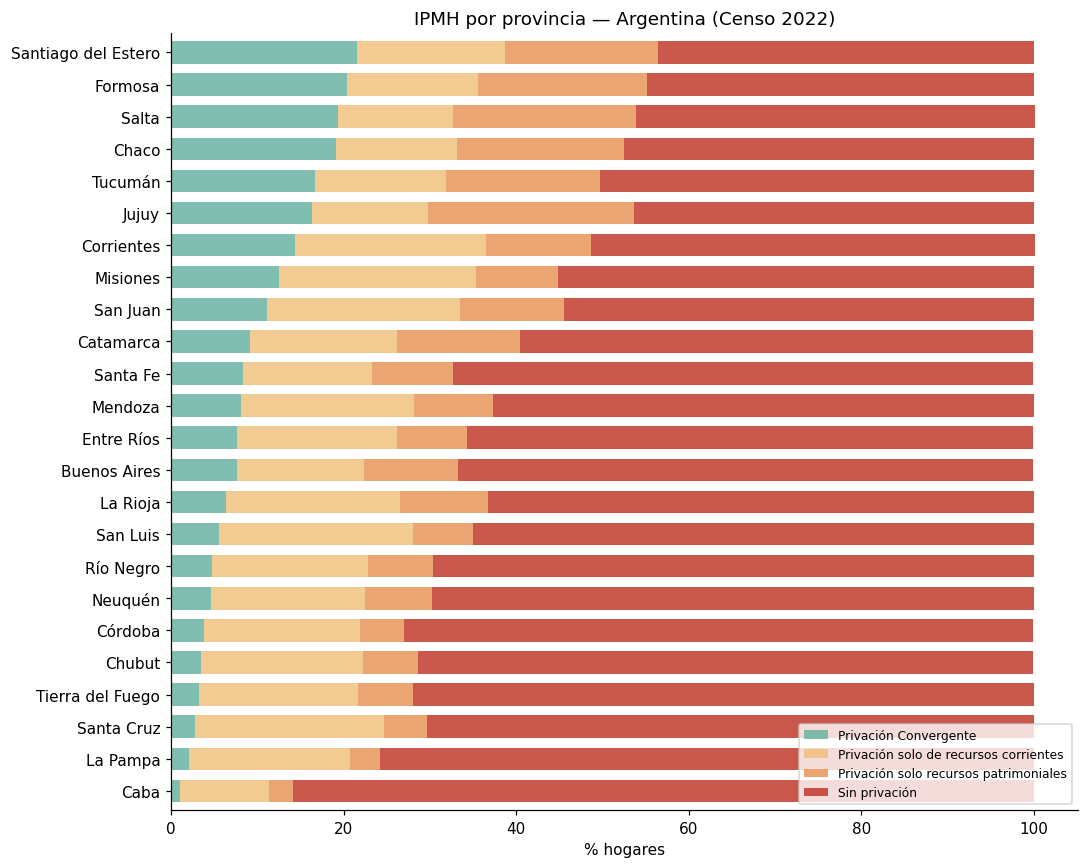

In [22]:
# Gráfico comparativo — todas las categorías de IPMH por provincia
cols_plot = [c for c in ipmh_prov.columns if c != "Total"]
plot_data = ipmh_prov[cols_plot].sort_values(cols_plot[0], ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colores = ["#69b3a2", "#f0c27f", "#e8965a", "#c0392b"]
plot_data.plot(kind="barh", stacked=True, ax=ax,
               color=colores[:len(cols_plot)], alpha=0.85, width=0.7)

ax.set_xlabel("% hogares")
ax.set_title("IPMH por provincia — Argentina (Censo 2022)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

---
## 8. Para seguir explorando

### Algunas variables interesantes para investigar

```python
# Acceso a servicios básicos
censo.tabla("VIVIENDA_URP")               # urbano vs rural
censo.comparar("VIVIENDA_TIPOVIVG")       # tipos de vivienda por provincia

# Demografía
censo.tabla("PERSONA_EDADGRU")            # grandes grupos de edad
censo.comparar("PERSONA_CONDACT")         # actividad económica

# Déficit habitacional
censo.comparar("HOGAR_NBI_VIV")           # NBI vivienda
censo.comparar("HOGAR_NBI_SAN")           # NBI saneamiento
censo.tabla("HOGAR_H20CP", provincia="Formosa")  # hacinamiento en Formosa
```

### Recursos

- [Dataset en Hugging Face](https://huggingface.co/datasets/pedroorden/censoargentino)
- [Definiciones de variables — INDEC (PDF)](https://redatam.indec.gob.ar/redarg/CENSOS/CPV2022/Docs/Redatam_Definiciones_de_la_base_de_datos.pdf)
- [Portal REDATAM online](https://redatam.indec.gob.ar/binarg/RpWebEngine.exe/Portal?BASE=CPV2022&lang=ESP)